In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans

In [2]:
csv_candidates = ["/content/Wine.csv"]
csv_path = None
for p in csv_candidates:
    if os.path.exists(p):
        csv_path = p
        break
if csv_path is None:
    raise FileNotFoundError("Wine.csv not found. Upload the file to Colab and re-run.")

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)
display(df.head())


Loaded: /content/Wine.csv
Shape: (178, 14)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [3]:
print("\nColumns:", list(df.columns))
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDtypes:")
print(df.dtypes)


Columns: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline', 'Customer_Segment']

Missing values per column:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

Dtypes:
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                 

In [4]:
label_column_name = None

if label_column_name is None:

    common_names = ['wine', 'type', 'class', 'wine_type', 'label', 'target', 'color',
                    'is_red', 'is_white', 'customer_segment', 'segment']
    found = [c for c in df.columns if c.lower() in common_names]
    if found:
        label_column_name = found[0]
    else:

        for c in df.columns:
            if df[c].dtype == object and df[c].nunique() == 2:
                label_column_name = c
                break

        if label_column_name is None:
            for c in df.columns:
                if np.issubdtype(df[c].dtype, np.number) and df[c].nunique() == 2:
                    label_column_name = c
                    break


if label_column_name is None:
    print("Could not auto-detect a binary label column. Candidate columns and their unique counts:")
    for c in df.columns:
        print(f" - {c}: dtype={df[c].dtype}, unique={df[c].nunique()}")
    raise KeyError("No suitable target column found. Set label_column_name manually to the correct column.")

print(f"Using label column: '{label_column_name}'")
target = df[label_column_name].copy()

if target.dtype == object or target.dtype.name == 'category':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(target.astype(str))
    print("Encoded target classes:", list(le.classes_))
else:

    y = target.values
    unique_vals = np.unique(y)
    print("Numeric target detected. Unique values:", unique_vals)

X = df.drop(columns=[label_column_name]).copy()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found in features. Make sure your dataset contains numeric measurement columns.")
X = X[numeric_cols].copy()
print("\nNumeric feature columns used for modeling:", numeric_cols)

X = X.reset_index(drop=True)
y = pd.Series(y).reset_index(drop=True)


Using label column: 'Customer_Segment'
Numeric target detected. Unique values: [1 2 3]

Numeric feature columns used for modeling: ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12, stratify=y)
print("\nTrain/Test shapes:", X_train.shape, X_test.shape)


Train/Test shapes: (142, 13) (36, 13)


In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=numeric_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=numeric_cols, index=X_test.index)

# Quick check
display(X_train_scaled.head())


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
93,-0.880853,0.409530,-0.505956,-0.451374,-0.838894,0.244014,0.234074,-0.813151,0.674564,-1.232347,0.800618,0.975030,-1.491072
62,0.852373,-1.000355,-1.572971,-0.451374,-0.434173,-0.314857,-0.238122,-0.260675,-1.485683,-0.515215,1.150912,-0.229918,-0.356172
116,-1.471154,-0.804042,-1.324001,0.398371,-0.973801,-0.506470,-0.433160,-0.418525,-0.114098,-1.319273,-0.075116,1.018063,-0.806794
172,1.467793,0.123984,0.418791,0.155587,-0.636533,-0.985502,-1.357023,0.686426,-0.611297,2.049076,-1.520077,-1.305764,-0.256034
74,-1.295320,-1.143128,-0.221418,0.459067,0.038002,1.729014,0.121158,-1.760252,0.091640,-0.771644,0.100031,0.731171,0.498340



Classification report (baseline logistic regression on all numeric features):
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



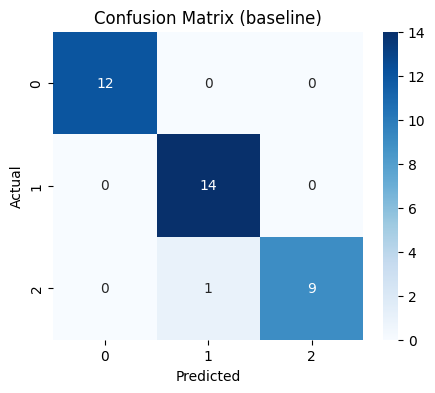

In [7]:
logreg = LogisticRegression(max_iter=2000, random_state=42)  # increased max_iter for convergence
logreg.fit(X_train_scaled, y_train)
y_pred_base = logreg.predict(X_test_scaled)
print("\nClassification report (baseline logistic regression on all numeric features):")
print(classification_report(y_test, y_pred_base))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [8]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)   # <<-- important: transform, do NOT fit again on test

print("\nExplained variance ratio by 2 PCs:", pca.explained_variance_ratio_)
print("Cumulative explained:", pca.explained_variance_ratio_.cumsum())

# Show component loadings (which features contribute)
loadings = pd.DataFrame(pca.components_.T, index=numeric_cols, columns=['PC1','PC2'])
display(loadings.sort_values('PC1', ascending=False).head(8))
display(loadings.sort_values('PC2', ascending=False).head(8))



Explained variance ratio by 2 PCs: [0.36394401 0.19527996]
Cumulative explained: [0.36394401 0.55922397]


,PC1,PC2
Flavanoids,0.427610,0.021041
Total_Phenols,0.395016,0.075564
OD280,0.382867,-0.128427
Proanthocyanins,0.305130,0.022424
Hue,0.292506,-0.255174
Proline,0.267169,0.390930
Magnesium,0.131757,0.319120
Alcohol,0.108515,0.498388


,PC1,PC2
Color_Intensity,-0.108156,0.504004
Alcohol,0.108515,0.498388
Proline,0.267169,0.390930
Ash,-0.035083,0.345485
Magnesium,0.131757,0.319120
Malic_Acid,-0.261073,0.186802
Total_Phenols,0.395016,0.075564
Proanthocyanins,0.305130,0.022424



Classification report (Logistic Regression on 2 PCA components):
              precision    recall  f1-score   support

           1       0.92      1.00      0.96        12
           2       0.93      0.93      0.93        14
           3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



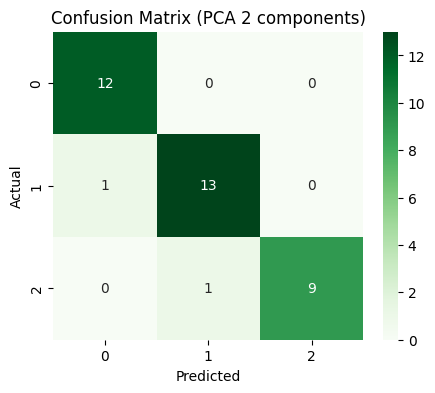

In [9]:
pc_model = LogisticRegression(max_iter=2000, random_state=42)
pc_model.fit(X_train_pca, y_train)
y_pred_pca = pc_model.predict(X_test_pca)

print("\nClassification report (Logistic Regression on 2 PCA components):")
print(classification_report(y_test, y_pred_pca))
cm_pca = confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(5,4))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (PCA 2 components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

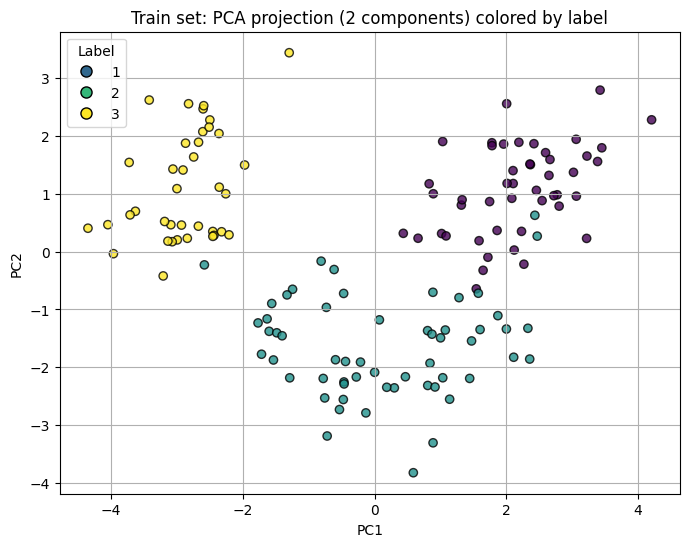

In [10]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', edgecolor='k', alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Train set: PCA projection (2 components) colored by label')
# create legend for discrete labels
handles = []
labels = np.unique(y_train)
for lab in labels:
    handles.append(plt.Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.viridis(lab/ (labels.max() if labels.max()>0 else 1)), markeredgecolor='k', markersize=8))
    # line above crafts a legend marker
plt.legend(handles, [str(l) for l in labels], title='Label', loc='best')
plt.grid(True)
plt.show()

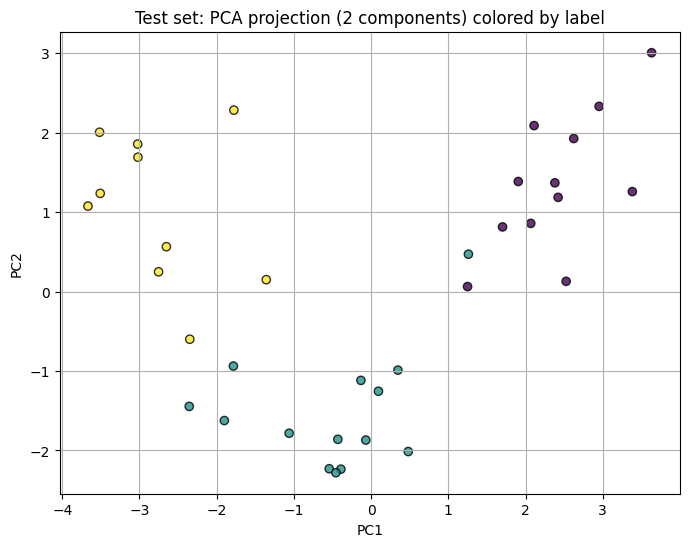

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=y_test, cmap='viridis', edgecolor='k', alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Test set: PCA projection (2 components) colored by label')
plt.grid(True)
plt.show()